<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/xRFM_TONIoT_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# xRFM settings
DEVICE = "cuda"   # use 'cpu' if no GPU available

print("Config loaded.")

Config loaded.


In [2]:
# Install Libraries

!pip install -q xrfm[cu12]
!pip install -q scikit-learn pandas numpy matplotlib seaborn

print("All packages installed restart runtime")

All packages installed restart runtime


In [3]:
# IMPORTS + DRIVE MOUNT + GPU CHECK

import os, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    precision_score, recall_score,
    roc_auc_score, cohen_kappa_score,
    matthews_corrcoef, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# GPU check
if not torch.cuda.is_available():
    print("WARNING: No GPU detected. xRFM will run on CPU (slower).")
    print("- Go to Runtime - Change runtime type - T4 GPU - Save")
    DEVICE = "cpu"
else:
    print(f"GPU confirmed : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"Device        : {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU confirmed : Tesla T4
VRAM          : 15.6 GB
Device        : cuda


In [4]:
# LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows   : {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows   : 211,043
Total columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
# PREPROCESS

# Drop label + non-feature columns
drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

# Encode string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Keep numeric features only + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features     : {X.shape[1]}")

# Split FIRST — 70 / 10 / 20 — before any imputation or scaling
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_tv
)
print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Impute NaN using TRAIN median only (no data leakage)
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scale using TRAIN statistics only (no data leakage)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print("Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features     : 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
Preprocessing complete — no data leakage


In [6]:
# EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ', '_')}_cm.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

print("Evaluation helper ready.")

Evaluation helper ready.


In [7]:
# xRFM TRAINING


from xrfm import xRFM

xrfm_model = xRFM(
    tuning_metric='accuracy',    # optimise for accuracy during internal HPO
    device=DEVICE,               # 'cuda' or 'cpu'
    min_subset_size=10000,       # minimum samples per tree leaf
    split_method='top_vector_agop_on_subset'  # AGOP-based splitting
)

print("Training xRFM on TON-IoT...")
print("(xRFM performs its own internal hyperparameter search — no manual tuning needed)")

t0 = time.time()

xrfm_model.fit(
    X_train_s, y_train,
    X_val_s,   y_val
)

train_time = time.time() - t0
print(f"\nxRFM training complete in {train_time:.1f}s ({train_time/60:.1f} min)")

None
Training xRFM on TON-IoT...
(xRFM performs its own internal hyperparameter search — no manual tuning needed)
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Using cheap batch size
Optimal M batch size: 3309
Time taken for round 4: 0.03533339500427246 seconds
Using cheap batch size
Optimal M batch size: 3309
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([10912, 17]) y_train torch.Size([10912, 10]) X_val torch.Size([575, 17]) y_val torch.Size([575, 10])
Fitting RFM with ntrain: 10912, d: 17, and nval: 575
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 0: 0.45229029655456543 seconds
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 1: 0.46699094772338867 seconds
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 2: 0.46965646743774414 seconds
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 3: 0.46466064453125 seconds
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 4: 0.46543288230895996 seconds
Using cheap batch size
Optimal M batch size: 3574

Building trees: 100%|██████████| 1/1 [14:26<00:00, 866.28s/it]


Using cheap batch size
Optimal M batch size: 3308
Time taken for round 0: 0.03053116798400879 seconds
Using cheap batch size
Optimal M batch size: 3308
Time taken for round 1: 0.036184072494506836 seconds
Using cheap batch size
Optimal M batch size: 3308
Time taken for round 2: 0.03623771667480469 seconds
Using cheap batch size
Optimal M batch size: 3308
Time taken for round 3: 0.03605484962463379 seconds
Using cheap batch size
Optimal M batch size: 3308
Time taken for round 4: 0.035135746002197266 seconds
Using cheap batch size
Optimal M batch size: 3308


Tuning split temperature: 100%|██████████| 36/36 [00:10<00:00,  3.58it/s]

Selected split_temperature=0.0 based on validation accuracy=0.980905

xRFM training complete in 876.5s (14.6 min)


Using hard routing for tree prediction
Using hard routing for tree prediction
Probability scores available for ROC-AUC.
Inference time : 0.15s for 42,209 samples
                (0.0035 ms per sample)

  xRFM — Results
  Accuracy      : 0.9801
  F1 (macro)    : 0.9446
  F1 (weighted) : 0.9800

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.97      0.96      0.97      4000
         dos       0.98      0.98      0.98      4000
   injection       0.97      0.94      0.96      4000
        mitm       0.68      0.60      0.64       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.98      0.98      4000
  ransomware       0.99      1.00      1.00      4000
    scanning       0.98      0.98      0.98      4000
         xss       0.92      0.97      0.94      4000

    accuracy                           0.98     42209
   macro avg       0.95      0.94      0.94     42209
w

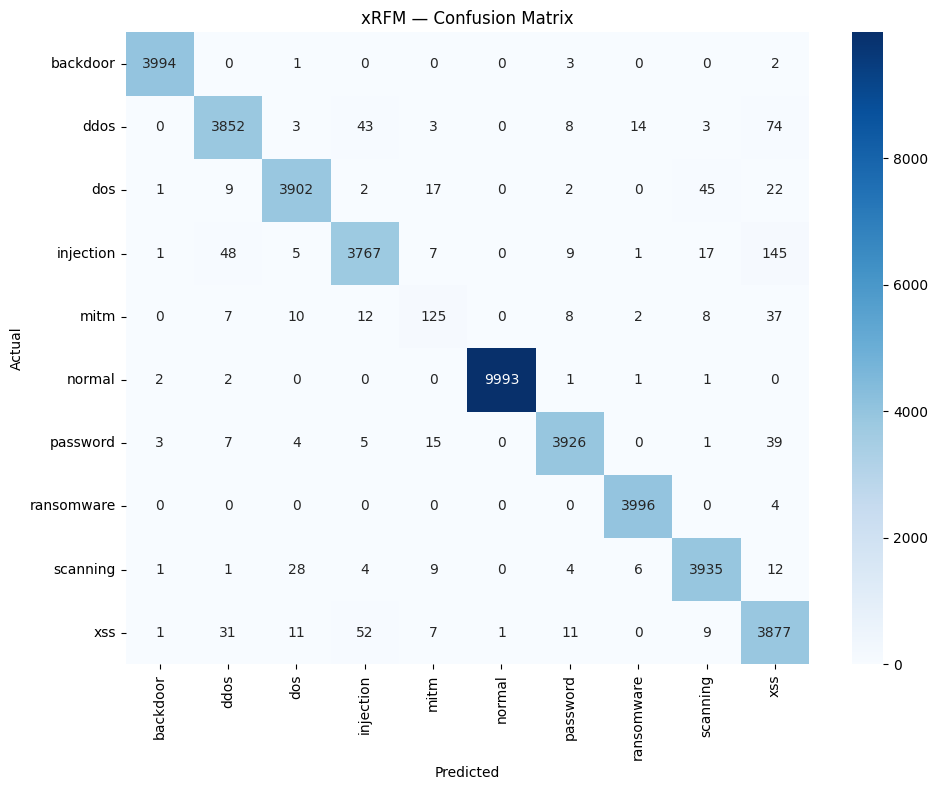

Saved: /content/drive/MyDrive/toniot_outputs/xrfm_cm.png


In [8]:
# xRFM TEST EVALUATION

t0 = time.time()
xrfm_preds = xrfm_model.predict(X_test_s)
infer_time = time.time() - t0

# Try to get probability scores for ROC-AUC
xrfm_proba = None
try:
    xrfm_proba = xrfm_model.predict_proba(X_test_s)
    print("Probability scores available for ROC-AUC.")
except:
    print("Note: xRFM predict_proba not available — ROC-AUC will be skipped.")

print(f"Inference time : {infer_time:.2f}s for {len(X_test_s):,} samples")
print(f"                ({infer_time / len(X_test_s) * 1000:.4f} ms per sample)")

xrfm_results = evaluate(
    "xRFM", y_test, xrfm_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

  TABLE 1: Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.9801
Precision (macro) 0.9490
   Recall (macro) 0.9410
       F1 (macro) 0.9446
    F1 (weighted) 0.9800
              MCC 0.9771
    Cohen's Kappa 0.9771
  ROC-AUC (macro) 0.9977



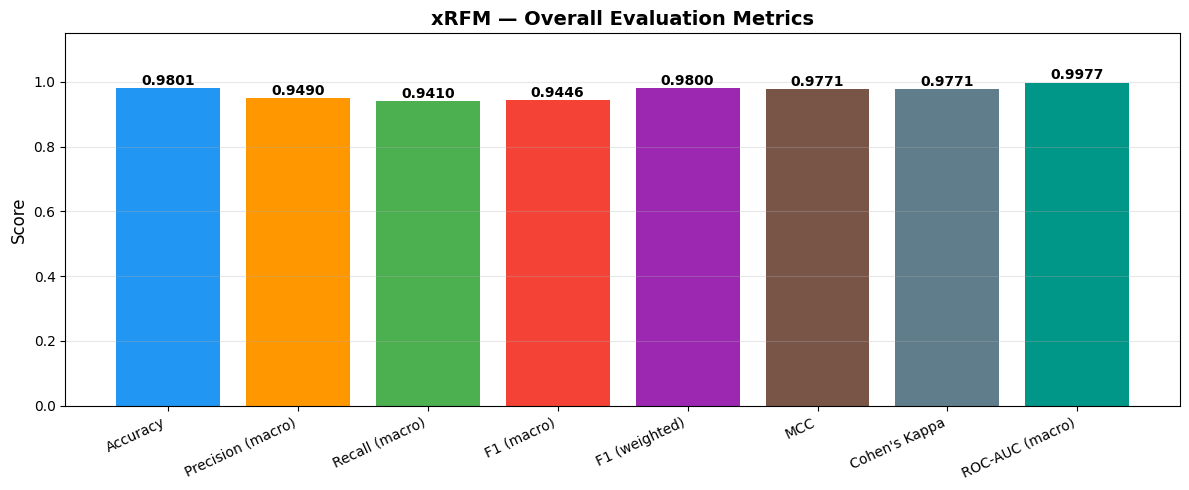

  TABLE 2: Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     0.9978  0.9985    0.9981     4000
      ddos     0.9735  0.9630    0.9682     4000
       dos     0.9844  0.9755    0.9799     4000
 injection     0.9696  0.9418    0.9555     4000
      mitm     0.6831  0.5981    0.6378      209
    normal     0.9999  0.9993    0.9996    10000
  password     0.9884  0.9815    0.9849     4000
ransomware     0.9940  0.9990    0.9965     4000
  scanning     0.9791  0.9838    0.9814     4000
       xss     0.9205  0.9692    0.9442     4000



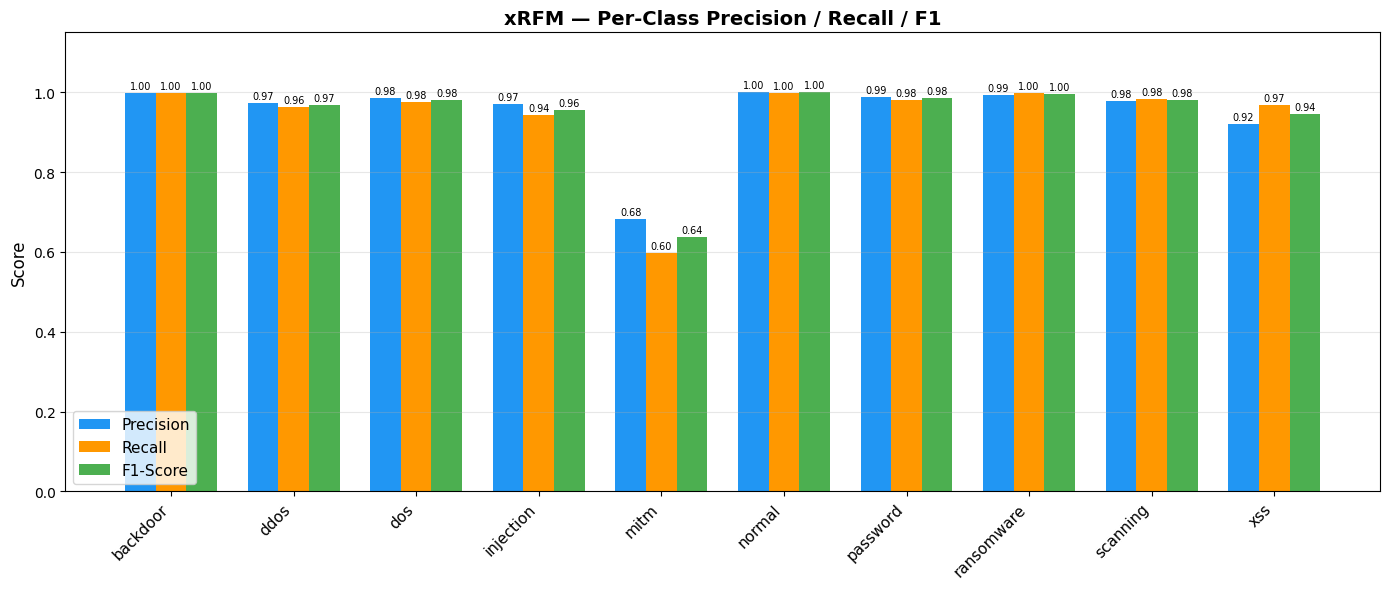

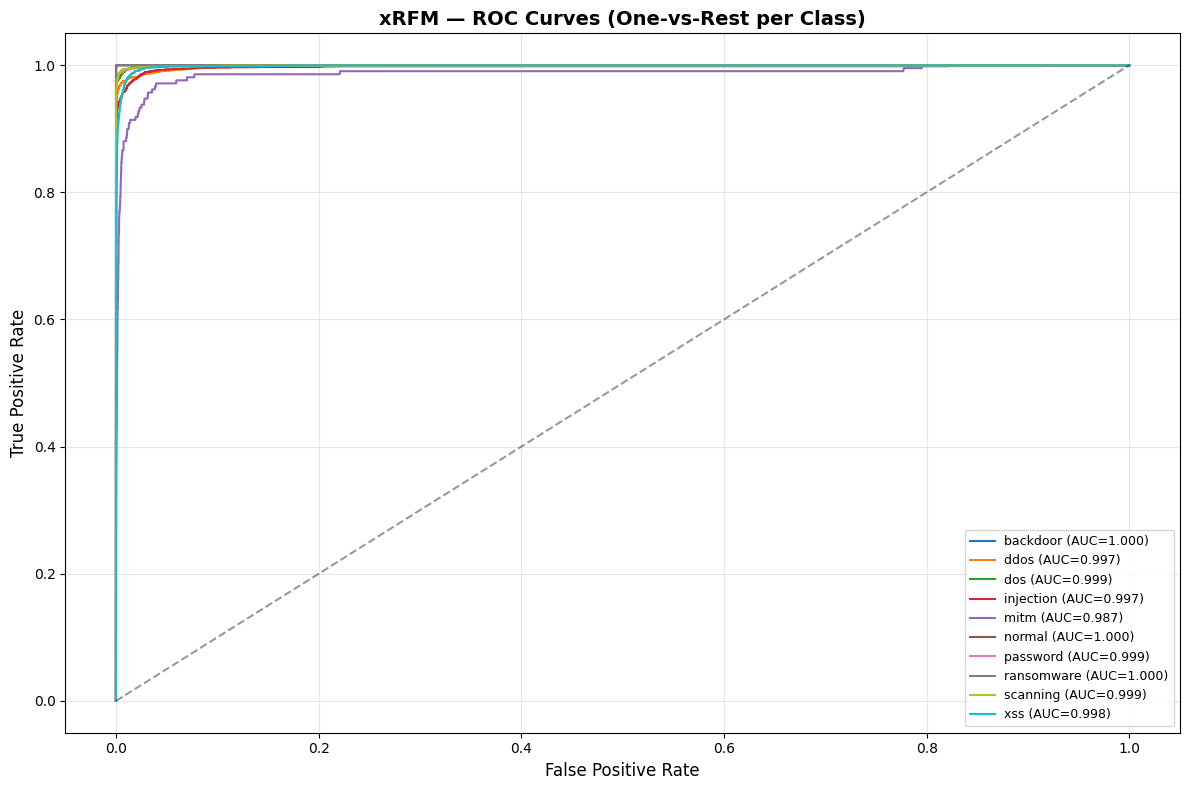

  TABLE 3: Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   1.0000
      ddos   0.9974
       dos   0.9992
 injection   0.9970
      mitm   0.9872
    normal   1.0000
  password   0.9986
ransomware   0.9999
  scanning   0.9992
       xss   0.9983

  Macro-average ROC-AUC: 0.9977

  TABLE 4: MCC & Cohen's Kappa Interpretation
                                Metric  Score Interpretation
MCC (Matthews Correlation Coefficient) 0.9771      Excellent
                         Cohen's Kappa 0.9771 Almost Perfect


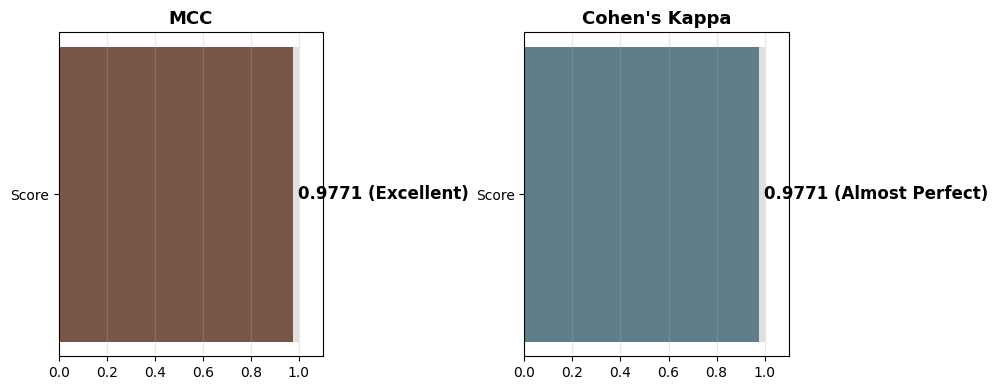

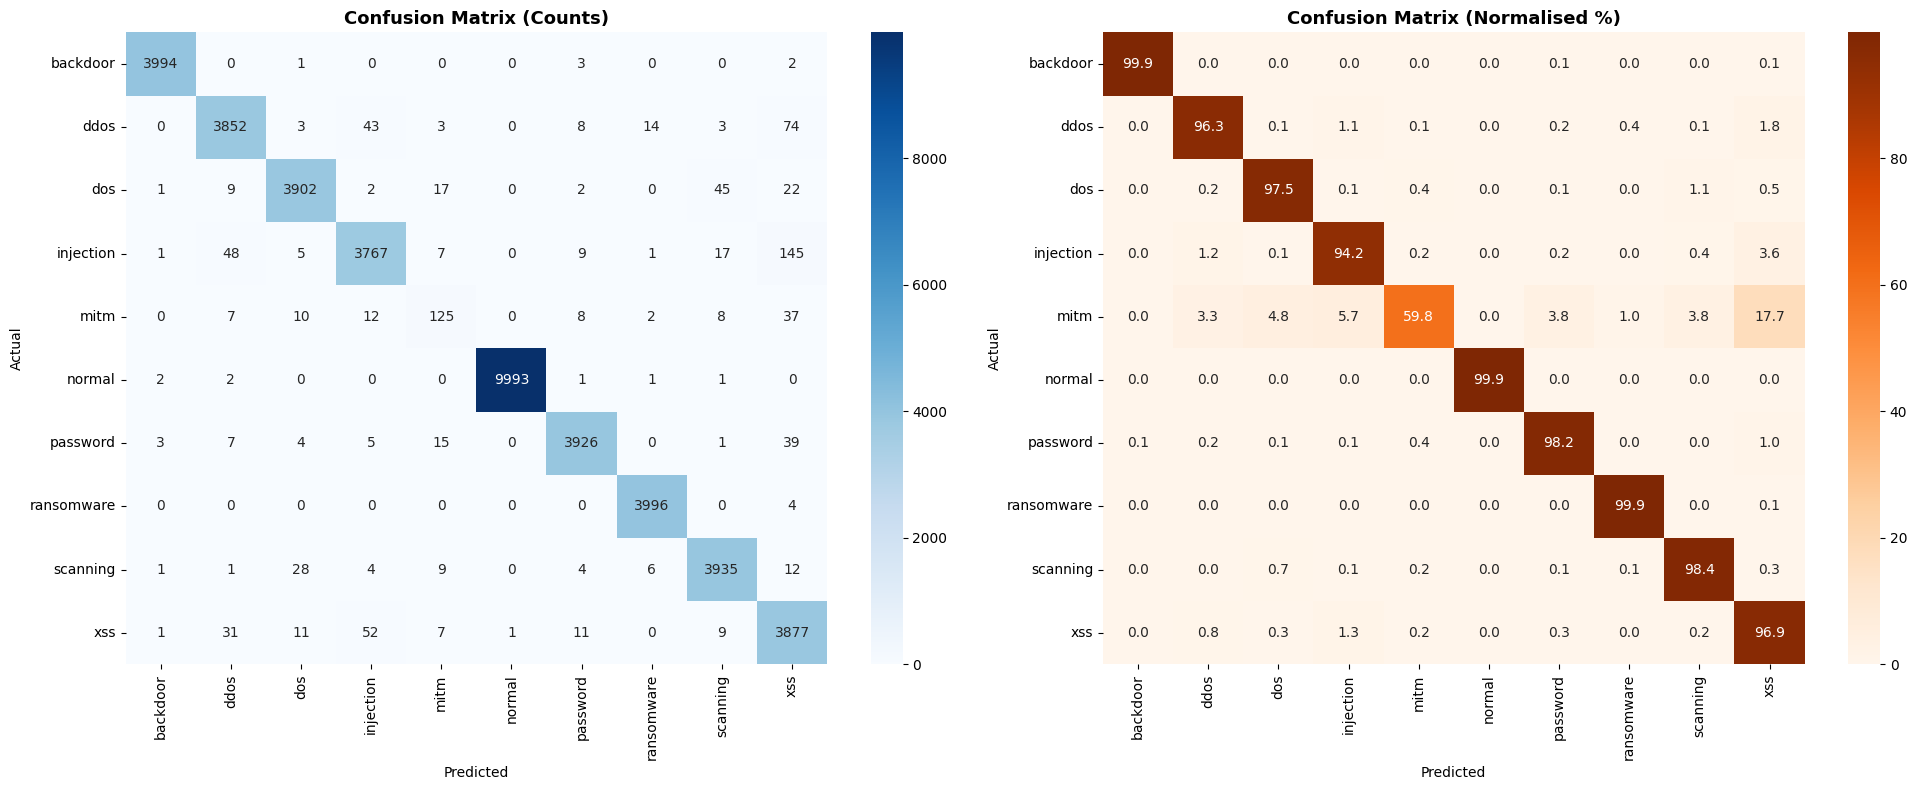


All visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [9]:
# TABLES & VISUALISATIONS

y_true = y_test
y_pred = xrfm_preds
y_prob = xrfm_proba

label_names = list(le.classes_)


# 1. MACRO METRICS SUMMARY TABLE + BAR CHART

acc         = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)
kappa       = cohen_kappa_score(y_true, y_pred)

roc_auc = None
if y_prob is not None:
    try:
        roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except:
        pass

macro_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1 (macro)", "F1 (weighted)", "MCC", "Cohen's Kappa",
               "ROC-AUC (macro)"],
    "Score": [acc, prec_macro, rec_macro, f1_macro, f1_weighted,
              mcc, kappa, roc_auc if roc_auc else float('nan')]
})
macro_df["Score"] = macro_df["Score"].round(4)

print("=" * 60)
print("  TABLE 1: Overall Evaluation Metrics")
print("=" * 60)
print(macro_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336",
          "#9C27B0", "#795548", "#607D8B", "#009688"]
valid = macro_df.dropna()
bars = ax.bar(valid["Metric"], valid["Score"], color=colors[:len(valid)])
for bar, val in zip(bars, valid["Score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("xRFM — Overall Evaluation Metrics", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "xrfm_macro_metrics.png"), dpi=150)
plt.show()


# 2. PER-CLASS PRECISION, RECALL, F1 TABLE + CHART

prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

perclass_df = pd.DataFrame({
    "Class": label_names,
    "Precision": np.round(prec_per, 4),
    "Recall": np.round(rec_per, 4),
    "F1-Score": np.round(f1_per, 4),
    "Support": [np.sum(y_true == c) for c in range(num_classes)]
})

print("=" * 60)
print("  TABLE 2: Per-Class Precision / Recall / F1")
print("=" * 60)
print(perclass_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names))
w = 0.25
b1 = ax.bar(x - w, prec_per, w, label="Precision", color="#2196F3")
b2 = ax.bar(x,     rec_per,  w, label="Recall",    color="#FF9800")
b3 = ax.bar(x + w, f1_per,   w, label="F1-Score",  color="#4CAF50")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("xRFM — Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "xrfm_perclass_prf.png"), dpi=150)
plt.show()


# 3. ROC-AUC PER CLASS — TABLE + CURVES

if y_prob is not None:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    auc_per_class = []
    fig, ax = plt.subplots(figsize=(12, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        class_auc = auc(fpr, tpr)
        auc_per_class.append(class_auc)
        ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={class_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("xRFM — ROC Curves (One-vs-Rest per Class)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_OUT_DIR, "xrfm_roc_curves.png"), dpi=150)
    plt.show()

    roc_df = pd.DataFrame({
        "Class": label_names,
        "ROC-AUC": np.round(auc_per_class, 4)
    })
    print("=" * 60)
    print("  TABLE 3: Per-Class ROC-AUC")
    print("=" * 60)
    print(roc_df.to_string(index=False))
    if roc_auc:
        print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")
else:
    print("\nROC-AUC curves skipped (predict_proba not available for xRFM).")


# 4. MCC & COHEN'S KAPPA — INTERPRETATION TABLE + VISUAL

def interpret_mcc(val):
    if val >= 0.9: return "Excellent"
    if val >= 0.7: return "Strong"
    if val >= 0.5: return "Moderate"
    if val >= 0.3: return "Weak"
    return "Poor"

def interpret_kappa(val):
    if val >= 0.81: return "Almost Perfect"
    if val >= 0.61: return "Substantial"
    if val >= 0.41: return "Moderate"
    if val >= 0.21: return "Fair"
    return "Slight/Poor"

agreement_df = pd.DataFrame({
    "Metric": ["MCC (Matthews Correlation Coefficient)",
               "Cohen's Kappa"],
    "Score": [round(mcc, 4), round(kappa, 4)],
    "Interpretation": [interpret_mcc(mcc), interpret_kappa(kappa)]
})

print()
print("=" * 60)
print("  TABLE 4: MCC & Cohen's Kappa Interpretation")
print("=" * 60)
print(agreement_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric_name, value, interp, color in [
    (axes[0], "MCC", mcc, interpret_mcc(mcc), "#795548"),
    (axes[1], "Cohen's Kappa", kappa, interpret_kappa(kappa), "#607D8B"),
]:
    ax.barh(["Score"], [value], color=color, height=0.4)
    ax.barh(["Score"], [1.0], color="#E0E0E0", height=0.4, zorder=0)
    ax.set_xlim(0, 1.1)
    ax.text(value + 0.02, 0, f"{value:.4f} ({interp})",
            va="center", fontsize=12, fontweight="bold")
    ax.set_title(metric_name, fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "xrfm_mcc_kappa.png"), dpi=150)
plt.show()

# 5. DUAL CONFUSION MATRIX (COUNTS + NORMALISED %)


cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Oranges",
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalised %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "xrfm_cm_dual.png"), dpi=150)
plt.show()

print("\nAll visualisations saved to:", DRIVE_OUT_DIR)

AGOP extraction note: 'xRFM' object has no attribute 'tree_'
Falling back to sklearn-style permutation importance...
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tree prediction
Using hard routing for tr

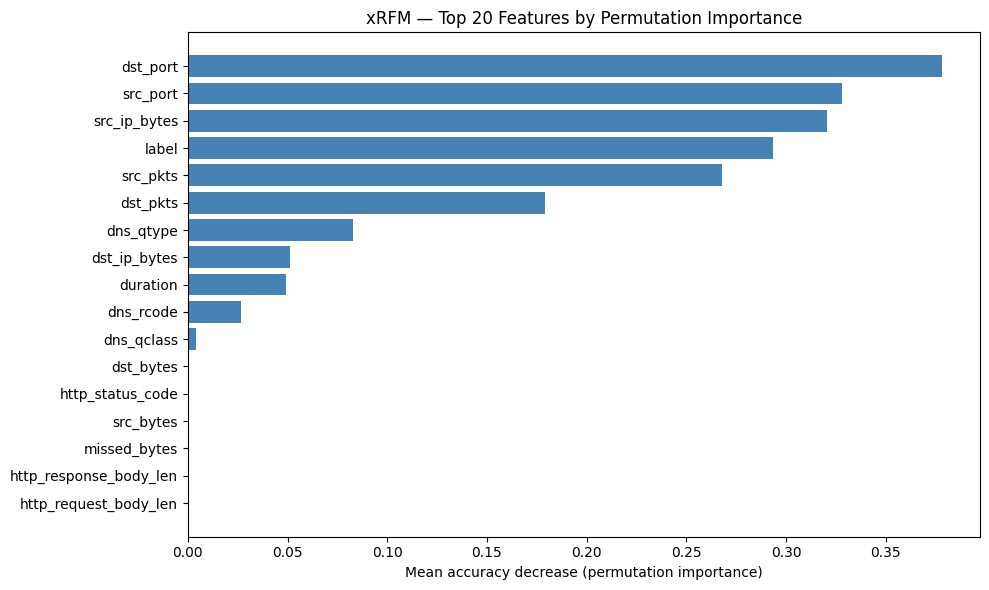

Permutation importance plot saved: /content/drive/MyDrive/toniot_outputs/xrfm_perm_importance.png


In [10]:
# AGOP FEATURE IMPORTANCE

feature_names = list(X_train.columns)

try:
    root_rfm = xrfm_model.tree_.leaf_models[0]  # adjust if API differs
    agop_diag = root_rfm.M.diagonal().cpu().numpy()

    # Normalise
    agop_diag = agop_diag / agop_diag.sum()

    top_n = 20
    top_idx = np.argsort(agop_diag)[::-1][:top_n]
    top_features = [feature_names[i] for i in top_idx]
    top_scores   = agop_diag[top_idx]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_scores[::-1], color="steelblue")
    plt.xlabel("Normalised AGOP diagonal (feature importance)")
    plt.title("xRFM — Top 20 Features by AGOP Importance")
    plt.tight_layout()
    fig_path = os.path.join(DRIVE_OUT_DIR, "xrfm_agop_importance.png")
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"AGOP feature importance plot saved: {fig_path}")

except Exception as e:
    print(f"AGOP extraction note: {e}")
    print("Falling back to sklearn-style permutation importance...")

    from sklearn.inspection import permutation_importance
    perm = permutation_importance(
        xrfm_model, X_test_s, y_test,
        n_repeats=5, random_state=RANDOM_SEED,
        scoring='accuracy'
    )
    top_n = 20
    top_idx = np.argsort(perm.importances_mean)[::-1][:top_n]
    top_features = [feature_names[i] for i in top_idx]
    top_scores   = perm.importances_mean[top_idx]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_scores[::-1], color="steelblue")
    plt.xlabel("Mean accuracy decrease (permutation importance)")
    plt.title("xRFM — Top 20 Features by Permutation Importance")
    plt.tight_layout()
    fig_path = os.path.join(DRIVE_OUT_DIR, "xrfm_perm_importance.png")
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"Permutation importance plot saved: {fig_path}")

In [11]:
# OVERFITTING / UNDERFITTING DIAGNOSIS

xrfm_train_preds = xrfm_model.predict(X_train_s)
xrfm_train_acc   = accuracy_score(y_train, xrfm_train_preds)
xrfm_train_f1    = f1_score(y_train, xrfm_train_preds, average="macro", zero_division=0)

print("-" * 50)
print("xRFM — Train vs Test Diagnosis")
print("-" * 50)
print(f"  Train Acc    : {xrfm_train_acc:.4f}")
print(f"  Test  Acc    : {xrfm_results['accuracy']:.4f}")
print(f"  Train F1     : {xrfm_train_f1:.4f}")
print(f"  Test  F1     : {xrfm_results['f1_macro']:.4f}")
print()

acc_gap = xrfm_train_acc - xrfm_results['accuracy']
if acc_gap > 0.05:
    print(f" Generalisation gap: {acc_gap:.4f} — possible overfitting")
elif xrfm_results['accuracy'] < 0.80:
    print("Low test accuracy — possible underfitting")
else:
    print(f" Generalisation gap: {acc_gap:.4f} — model generalises well")

print(f"\n  Training time : {train_time:.1f}s")
print(f"  Inference time: {infer_time:.2f}s ({len(X_test_s):,} samples)")

Using hard routing for tree prediction
--------------------------------------------------
xRFM — Train vs Test Diagnosis
--------------------------------------------------
  Train Acc    : 0.9870
  Test  Acc    : 0.9801
  Train F1     : 0.9650
  Test  F1     : 0.9446

 Generalisation gap: 0.0069 — model generalises well

  Training time : 876.5s
  Inference time: 0.15s (42,209 samples)


In [12]:
# SAVE RESULTS

results_df = pd.DataFrame([{
    "model"           : "xRFM",
    "paper"           : "arXiv:2508.10053 (2025)",
    "dataset"         : "TON-IoT Network",
    "train_samples"   : len(X_train),
    "test_samples"    : len(X_test),
    "n_features"      : n_features,
    "n_classes"       : num_classes,
    "accuracy"        : acc,
    "f1_macro"        : f1_macro,
    "f1_weighted"     : f1_weighted,
    "precision_macro" : prec_macro,
    "recall_macro"    : rec_macro,
    "mcc"             : mcc,
    "cohen_kappa"     : kappa,
    "roc_auc_macro"   : roc_auc,
    "train_acc"       : xrfm_train_acc,
    "train_f1"        : xrfm_train_f1,
    "train_time_s"    : round(train_time, 2),
    "infer_time_s"    : round(infer_time, 4),
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "xrfm_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n========== FINAL RESULTS ==========")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


========== FINAL RESULTS ==========
                                       0
model                               xRFM
paper            arXiv:2508.10053 (2025)
dataset                  TON-IoT Network
train_samples                     147729
test_samples                       42209
n_features                            17
n_classes                             10
accuracy                        0.980052
f1_macro                        0.944618
f1_weighted                     0.979995
precision_macro                 0.949018
recall_macro                    0.940964
mcc                             0.977143
cohen_kappa                     0.977123
roc_auc_macro                    0.99767
train_acc                       0.986969
train_f1                        0.965043
train_time_s                      876.49
infer_time_s                      0.1461

Results saved to: /content/drive/MyDrive/toniot_outputs/xrfm_toniot_results.csv
